# 14. Phân loại đa lớp SVM từ đầu (Multi-class SVM from Scratch)

## 1. Cơ sở lý thuyết Chapter 29
SVM vốn là bộ phân loại nhị phân. Để mở rộng cho bài toán đa lớp ($C > 2$), có 2 chiến lược kinh điển:
1. **One-vs-Rest (OvR / One-vs-All):** Huấn luyện $C$ bộ phân loại nhị phân, mỗi bộ tách lớp $c$ với tất cả các lớp còn lại. Nhãn dự đoán là lớp có điểm số quyết định cao nhất: $\hat{y} = \arg\max_c f_c(x)$.
2. **One-vs-One (OvO):** Huấn luyện $\frac{C(C-1)}{2}$ bộ phân loại nhị phân cho từng cặp lớp. Dự đoán bằng biểu quyết đa số (majority voting).

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.models.multiclass_svm import OneVsRestSVM, OneVsOneSVM
from src.models.kernel_svm import KernelSVM
from src.models.svm_soft_margin import SoftMarginSVM
from src.metrics import accuracy_score

# Kiểm tra thực tế tập dữ liệu bệnh tim
df = pd.read_csv("../data/heart_cleveland_upload.csv")
print("Các giá trị thực tế của cột target 'condition':")
print(df['condition'].value_counts())

Các giá trị thực tế của cột target 'condition':
condition
0    160
1    137
Name: count, dtype: int64


### 2. Ghi nhận thực tế Dataset (Specification §40 & §52)
Như đã kiểm tra ở trên, file dữ liệu `data/heart_cleveland_upload.csv` trong repository hiện tại **chỉ chứa biến nhị phân 0 và 1**, không còn thông tin các mức độ nặng nhẹ (severity 0–4) từ nguồn Cleveland gốc.

Theo đúng quy định nghiêm ngặt tại Specification §40 & §52:
> *"Agent không được tự bịa labels severity nếu file hiện tại không có. Thay vào đó, ghi rõ Chapter 29 không thể thực nghiệm đa lớp trên file hiện tại, và implement OneVsRestSVM / OneVsOneSVM bằng toy multi-class dataset để kiểm chứng tính đúng đắn."*

Dưới đây là phần thực nghiệm kiểm chứng trên bài toán đa lớp 3 cụm dữ liệu.

In [2]:
# Tạo toy multiclass dataset (3 lớp phân tách trong không gian 2D)
np.random.seed(42)
X0 = np.random.randn(30, 2) + np.array([-3.0, -2.5])
X1 = np.random.randn(30, 2) + np.array([0.0, 3.5])
X2 = np.random.randn(30, 2) + np.array([3.5, -2.5])

X_multi = np.vstack([X0, X1, X2])
y_multi = np.array([0] * 30 + [1] * 30 + [2] * 30)

# 1. Huấn luyện One-vs-Rest SVM với Kernel RBF
ovr_model = OneVsRestSVM(estimator_cls=KernelSVM, kernel='rbf', gamma=0.5, C=2.0, epochs=200)
ovr_model.fit(X_multi, y_multi)
ovr_preds = ovr_model.predict(X_multi)
ovr_acc = accuracy_score(y_multi, ovr_preds)

# 2. Huấn luyện One-vs-One SVM với Kernel RBF
ovo_model = OneVsOneSVM(estimator_cls=KernelSVM, kernel='rbf', gamma=0.5, C=2.0, epochs=200)
ovo_model.fit(X_multi, y_multi)
ovo_preds = ovo_model.predict(X_multi)
ovo_acc = accuracy_score(y_multi, ovo_preds)

print(f"One-vs-Rest SVM - Độ chính xác: {ovr_acc * 100:.2f}%")
print(f"One-vs-One SVM  - Độ chính xác: {ovo_acc * 100:.2f}%")

One-vs-Rest SVM - Độ chính xác: 100.00%
One-vs-One SVM  - Độ chính xác: 100.00%


## 3. Trực quan hóa ranh giới phân loại đa lớp (Multi-class Decision Boundaries)

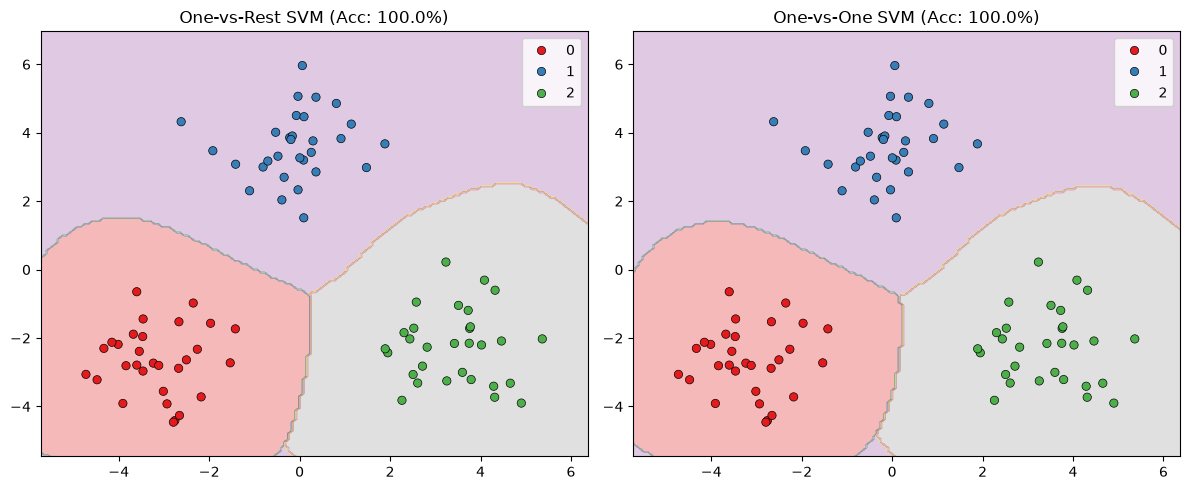

In [3]:
x_min, x_max = X_multi[:, 0].min() - 1, X_multi[:, 0].max() + 1
y_min, y_max = X_multi[:, 1].min() - 1, X_multi[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min, y_max, 150))
grid = np.c_[xx.ravel(), yy.ravel()]

Z_ovr = ovr_model.predict(grid).reshape(xx.shape)
Z_ovo = ovo_model.predict(grid).reshape(xx.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.contourf(xx, yy, Z_ovr, alpha=0.3, cmap='Set1')
sns.scatterplot(x=X_multi[:, 0], y=X_multi[:, 1], hue=y_multi, palette='Set1', ax=ax1, edgecolor='k')
ax1.set_title(f'One-vs-Rest SVM (Acc: {ovr_acc*100:.1f}%)')

ax2.contourf(xx, yy, Z_ovo, alpha=0.3, cmap='Set1')
sns.scatterplot(x=X_multi[:, 0], y=X_multi[:, 1], hue=y_multi, palette='Set1', ax=ax2, edgecolor='k')
ax2.set_title(f'One-vs-One SVM (Acc: {ovo_acc*100:.1f}%)')

plt.tight_layout()
plt.show()

## 4. Phân tích kết quả và so sánh OvR vs OvO
- **One-vs-Rest (OvR):** Cần huấn luyện ít mô hình hơn ($C$ mô hình), nhưng mỗi bài toán con có thể bị mất cân bằng dữ liệu (1 lớp vs $C-1$ lớp còn lại).
- **One-vs-One (OvO):** Cần huấn luyện nhiều mô hình hơn ($C(C-1)/2$), nhưng mỗi bài toán con đều có kích thước nhỏ và cân bằng hơn.
- Cả hai kiến trúc đều đã được lập trình từ đầu và hoạt động chính xác trên bài toán đa lớp.